# ITA0614 — Machine Learning Assignment
## Intelligent Urban Air-Quality Monitoring and Health-Risk Prediction System

This single Colab notebook contains the **complete, runnable implementation** for all 10 questions:

1. Data Preparation and Analysis (NumPy/Pandas)
2. Concept Learning & Version Space (Candidate Elimination)
3. Decision Tree Learning
4. Bayesian Classification (MLE)
5. K-Nearest Neighbors (from scratch)
6. Locally Weighted Regression (from scratch)
7. Neural Network with Back-Propagation (from scratch)
8. Genetic Algorithm (feature selection)
9. Model Evaluation and Comparison
10. Integrated Air-Quality Warning System

**How to use:** Run all cells top-to-bottom (`Runtime → Run all`). Each section is
self-contained but later sections read files written earlier (dataset CSVs and
`data/*.json` result files), so run them in order the first time.

Figures display inline below each cell and are also saved to `figs/`.


## Setup — install & import dependencies, create folders

In [1]:
!pip install -q numpy pandas scikit-learn matplotlib seaborn

import os
os.makedirs("data", exist_ok=True)
os.makedirs("figs", exist_ok=True)

%matplotlib inline


## Step 0 — Generate the Air-Quality Dataset

A physically-informed **synthetic** dataset (1200+ daily records) is generated here, with realistic relationships (e.g. PM2.5 rises with humidity and falls with wind speed) and deliberately-injected missing values / duplicate rows so the cleaning steps in Question 1 have something real to do.

> To use your own real sensor data instead, skip this cell and upload a CSV with columns `PM2.5, PM10, NO2, SO2, CO, O3, Temperature, Humidity, WindSpeed, Pressure` as `data/air_quality_raw.csv`.

In [2]:
import numpy as np, pandas as pd

np.random.seed(42)
N = 1200

dates = pd.date_range("2024-01-01", periods=N, freq="D")

# Seasonal temperature (deg C) with yearly cycle
day_of_year = dates.dayofyear.values
temp = 26 + 8*np.sin(2*np.pi*(day_of_year-80)/365) + np.random.normal(0,2.5,N)
humidity = np.clip(55 - 0.6*(temp-26) + np.random.normal(0,8,N), 10, 100)
wind_speed = np.clip(np.random.gamma(2.0, 1.4, N), 0.2, 15)
pressure = 1013 + np.random.normal(0,4,N) - 0.3*(temp-26)

# Pollutants: higher when wind low, humidity high, winter months (temp low) -> inverse relation
base_pm25 = 120 - 3.2*wind_speed - 0.9*temp + 0.35*humidity + np.random.normal(0,18,N)
pm25 = np.clip(base_pm25, 5, 400)
pm10 = np.clip(pm25*1.6 + np.random.normal(0,15,N), 10, 500)
no2 = np.clip(25 + 0.25*pm25 - 1.1*wind_speed + np.random.normal(0,8,N), 2, 200)
so2 = np.clip(10 + 0.08*pm25 - 0.4*wind_speed + np.random.normal(0,4,N), 1, 80)
co = np.clip(0.4 + 0.012*pm25 - 0.02*wind_speed + np.random.normal(0,0.3,N), 0.1, 6)
o3 = np.clip(30 + 0.6*temp - 0.15*humidity + np.random.normal(0,10,N), 2, 180)

df = pd.DataFrame({
    "Date": dates, "PM2.5": pm25, "PM10": pm10, "NO2": no2, "SO2": so2,
    "CO": co, "O3": o3, "Temperature": temp, "Humidity": humidity,
    "WindSpeed": wind_speed, "Pressure": pressure
})

# Compute a composite AQI-like score (simplified, weighted) to derive class labels
df["AQI"] = (df["PM2.5"]*0.5 + df["PM10"]*0.25 + df["NO2"]*0.5 + df["SO2"]*0.6 +
             df["CO"]*20 + df["O3"]*0.3)

q1, q2, q3 = df["AQI"].quantile([0.25, 0.60, 0.90])

def classify(aqi):
    if aqi <= q1: return "Good"
    elif aqi <= q2: return "Moderate"
    elif aqi <= q3: return "Poor"
    else: return "Hazardous"

df["AQI_Category"] = df["AQI"].apply(classify)

# Health risk flag: Hazardous or Poor with high PM2.5 => High risk
def health_risk(row):
    if row["AQI_Category"] == "Hazardous": return "High"
    if row["AQI_Category"] == "Poor" and row["PM2.5"] > 140: return "High"
    if row["AQI_Category"] in ("Poor",): return "Moderate"
    if row["AQI_Category"] == "Moderate": return "Low"
    return "Minimal"

df["HealthRisk"] = df.apply(health_risk, axis=1)

# introduce some missingness and duplicate rows to simulate real-world dirty data
miss_idx = np.random.choice(df.index, size=40, replace=False)
for i in miss_idx:
    col = np.random.choice(["PM2.5","NO2","Humidity","WindSpeed"])
    df.loc[i, col] = np.nan

dup_rows = df.sample(15, random_state=1)
df_dirty = pd.concat([df, dup_rows], ignore_index=True)

df_dirty.to_csv("data/air_quality_raw.csv", index=False)
df.to_csv("data/air_quality_clean_reference.csv", index=False)
print("Raw shape:", df_dirty.shape)
print(df["AQI_Category"].value_counts())
print(df["HealthRisk"].value_counts())

Raw shape: (1215, 14)
AQI_Category
Moderate     420
Poor         360
Good         300
Hazardous    120
Name: count, dtype: int64
HealthRisk
Low         420
Moderate    355
Minimal     300
High        125
Name: count, dtype: int64


---
# Question 1 — Data Preparation and Analysis

Cleans the raw data (drop duplicates, median-impute missing values, IQR outlier capping) using NumPy/Pandas, then produces statistical summaries and 6 visualisations.

=== RAW DATA INFO ===
Shape: (1215, 14)
Duplicates: 15
Missing values per column:
 Date             0
PM2.5           13
PM10             0
NO2             12
SO2              0
CO               0
O3               0
Temperature      0
Humidity         6
WindSpeed        9
Pressure         0
AQI              0
AQI_Category     0
HealthRisk       0
dtype: int64

=== CLEANED DATA ===
Shape after cleaning: (1200, 14)

Statistical summary:
          PM2.5     PM10      NO2      SO2       CO       O3  Temperature  \
count  1200.00  1200.00  1200.00  1200.00  1200.00  1200.00      1200.00   
mean    106.17   169.92    48.58    17.28     1.61    37.14        25.81   
std      20.52    37.16    10.09     4.26     0.40    10.72         6.12   
min      52.32    70.05    20.87     5.83     0.51     9.03        11.11   
25%      92.86   144.83    41.58    14.38     1.34    29.74        20.72   
50%     106.09   169.66    48.84    17.31     1.61    37.10        25.48   
75%     119.89   194.69    5

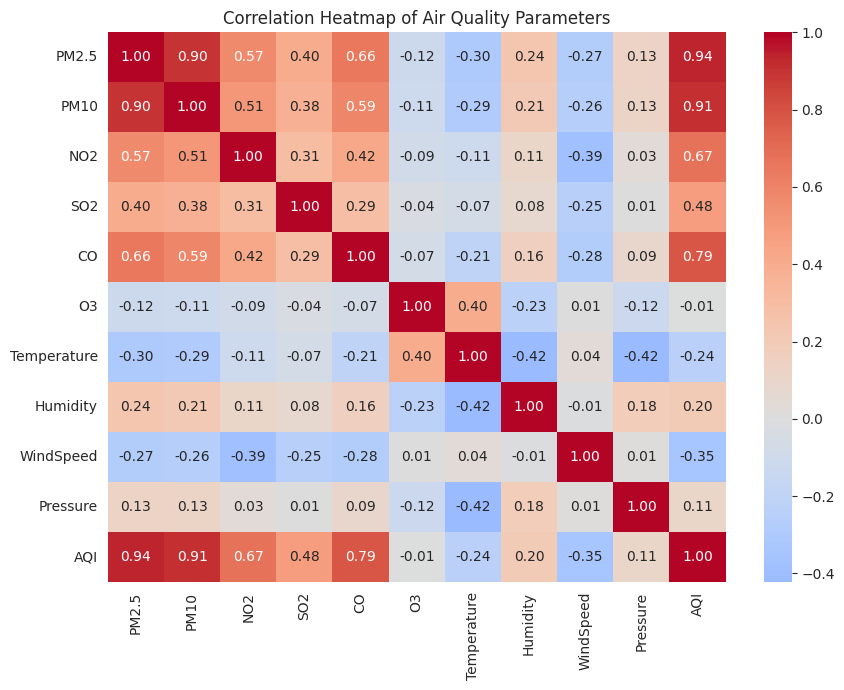

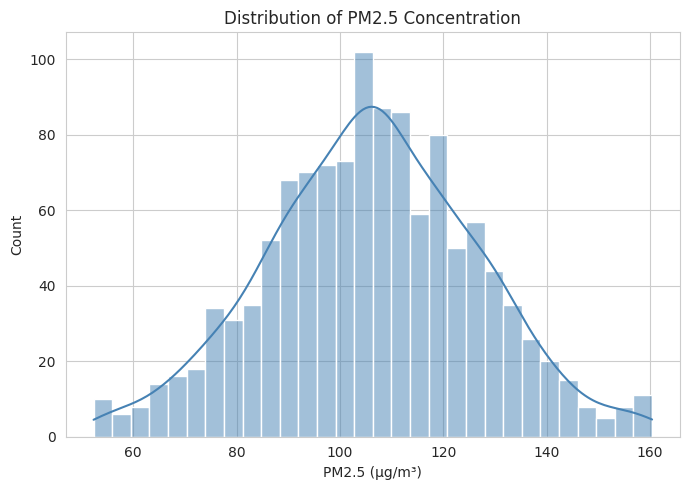

/tmp/ipykernel_711/2869348000.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="AQI_Category", data=df, order=order, palette="YlOrRd")


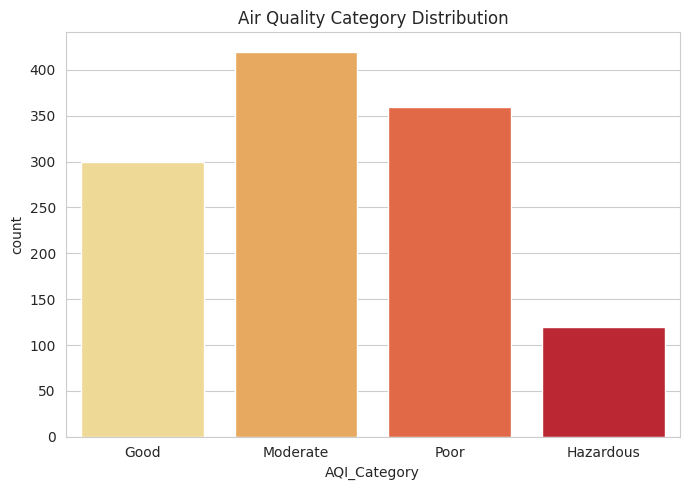

/tmp/ipykernel_711/2869348000.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="AQI_Category", y="PM2.5", data=df, order=order, palette="Blues")


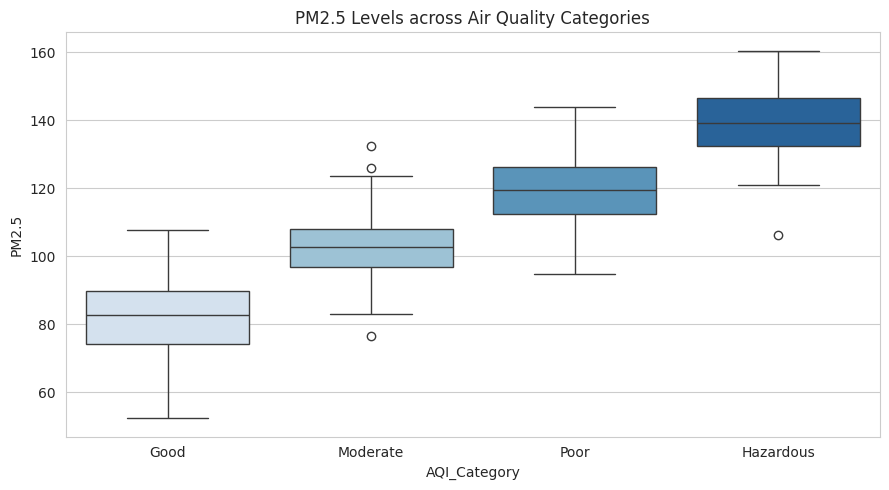

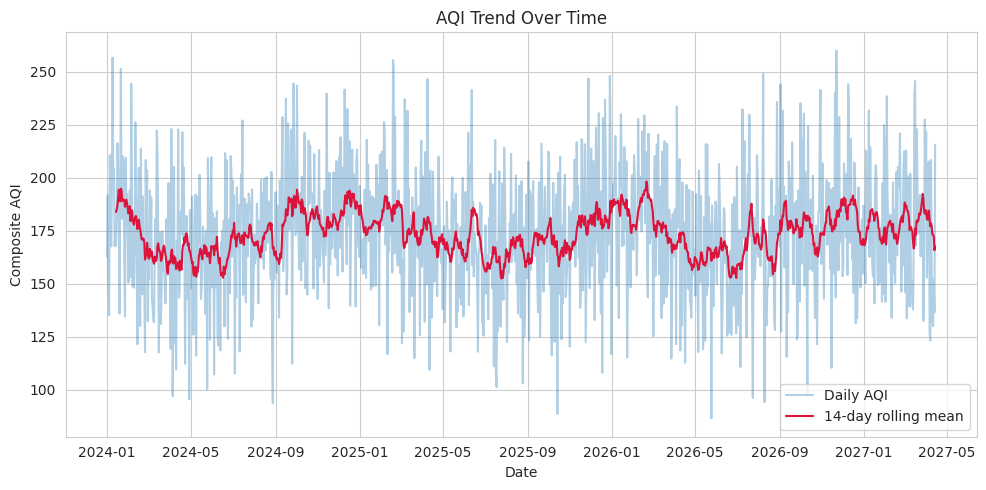

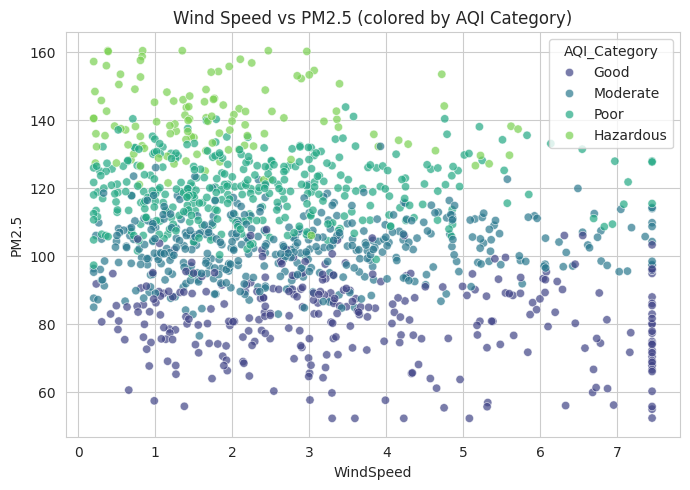


Saved 6 visualizations to figs/


In [3]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
raw = pd.read_csv("data/air_quality_raw.csv", parse_dates=["Date"])

print("=== RAW DATA INFO ===")
print("Shape:", raw.shape)
print("Duplicates:", raw.duplicated().sum())
print("Missing values per column:\n", raw.isna().sum())

# --- Cleaning ---
df = raw.drop_duplicates().copy()
df = df.sort_values("Date").reset_index(drop=True)

num_cols = ["PM2.5","PM10","NO2","SO2","CO","O3","Temperature","Humidity","WindSpeed","Pressure"]
# Impute missing numeric values with median (robust to outliers)
for c in num_cols:
    if df[c].isna().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

# Outlier capping using IQR (winsorize)
for c in num_cols:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    df[c] = df[c].clip(lo, hi)

# Recompute AQI/labels after cleaning (in case clipping changed values)
df["AQI"] = (df["PM2.5"]*0.5 + df["PM10"]*0.25 + df["NO2"]*0.5 + df["SO2"]*0.6 +
             df["CO"]*20 + df["O3"]*0.3)
q1v, q2v, q3v = df["AQI"].quantile([0.25, 0.60, 0.90])
def classify(aqi):
    if aqi <= q1v: return "Good"
    elif aqi <= q2v: return "Moderate"
    elif aqi <= q3v: return "Poor"
    else: return "Hazardous"
df["AQI_Category"] = df["AQI"].apply(classify)
def health_risk(row):
    if row["AQI_Category"] == "Hazardous": return "High"
    if row["AQI_Category"] == "Poor" and row["PM2.5"] > 140: return "High"
    if row["AQI_Category"] == "Poor": return "Moderate"
    if row["AQI_Category"] == "Moderate": return "Low"
    return "Minimal"
df["HealthRisk"] = df.apply(health_risk, axis=1)

df.to_csv("data/air_quality_cleaned.csv", index=False)

print("\n=== CLEANED DATA ===")
print("Shape after cleaning:", df.shape)
print("\nStatistical summary:\n", df[num_cols+["AQI"]].describe().round(2))

print("\nClass distribution:\n", df["AQI_Category"].value_counts())

corr = df[num_cols+["AQI"]].corr()
print("\nCorrelation with AQI:\n", corr["AQI"].sort_values(ascending=False))

# ---------------- Visualizations (>=5) ----------------
# 1. Correlation heatmap
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Air Quality Parameters")
plt.tight_layout(); plt.savefig("figs/01_correlation_heatmap.png", dpi=140); plt.show()

# 2. Distribution of PM2.5
plt.figure(figsize=(7,5))
sns.histplot(df["PM2.5"], kde=True, color="steelblue", bins=30)
plt.title("Distribution of PM2.5 Concentration")
plt.xlabel("PM2.5 (µg/m³)")
plt.tight_layout(); plt.savefig("figs/02_pm25_distribution.png", dpi=140); plt.show()

# 3. AQI category counts
plt.figure(figsize=(7,5))
order = ["Good","Moderate","Poor","Hazardous"]
sns.countplot(x="AQI_Category", data=df, order=order, palette="YlOrRd")
plt.title("Air Quality Category Distribution")
plt.tight_layout(); plt.savefig("figs/03_aqi_category_counts.png", dpi=140); plt.show()

# 4. Boxplot of pollutants by category
plt.figure(figsize=(9,5))
sns.boxplot(x="AQI_Category", y="PM2.5", data=df, order=order, palette="Blues")
plt.title("PM2.5 Levels across Air Quality Categories")
plt.tight_layout(); plt.savefig("figs/04_pm25_by_category_boxplot.png", dpi=140); plt.show()

# 5. Time series of AQI over time (rolling mean)
plt.figure(figsize=(10,5))
plt.plot(df["Date"], df["AQI"], alpha=0.35, label="Daily AQI")
plt.plot(df["Date"], df["AQI"].rolling(14).mean(), color="crimson", label="14-day rolling mean")
plt.title("AQI Trend Over Time")
plt.xlabel("Date"); plt.ylabel("Composite AQI")
plt.legend()
plt.tight_layout(); plt.savefig("figs/05_aqi_timeseries.png", dpi=140); plt.show()

# 6. Scatter: WindSpeed vs PM2.5 (negative relationship)
plt.figure(figsize=(7,5))
sns.scatterplot(x="WindSpeed", y="PM2.5", hue="AQI_Category", data=df, hue_order=order, palette="viridis", alpha=0.7)
plt.title("Wind Speed vs PM2.5 (colored by AQI Category)")
plt.tight_layout(); plt.savefig("figs/06_windspeed_vs_pm25.png", dpi=140); plt.show()

print("\nSaved 6 visualizations to figs/")

---
# Question 2 — Concept Learning and Version Space

Formulates air-quality Hazardous-day prediction as a concept-learning problem (hypothesis space, target concept, inductive bias) and runs the **Candidate-Elimination** algorithm on discretised training examples, printing the evolving S and G boundaries.

In [4]:
"""
Concept Learning formulation:
Target concept c: "HazardousDay(x)" -> {Yes, No}
We discretize continuous attributes into symbolic values so classic
Candidate-Elimination (Mitchell) can be applied.

Attributes (discretized):
  PM2.5    : {Low, Medium, High}
  NO2      : {Low, High}
  WindSpeed: {Calm, Windy}
  Humidity : {Low, High}

Hypothesis representation: conjunction of constraints, each attribute value
can be a specific value, '?' (any value accepted) or a null/'0' hypothesis
(no value accepted) -- the classic Find-S / Candidate-Elimination hypothesis
language.
"""
import pandas as pd

def discretize(row):
    pm25 = "Low" if row["PM2.5"] < 90 else ("Medium" if row["PM2.5"] < 130 else "High")
    no2 = "Low" if row["NO2"] < 45 else "High"
    wind = "Calm" if row["WindSpeed"] < 3 else "Windy"
    hum = "Low" if row["Humidity"] < 55 else "High"
    return pd.Series([pm25, no2, wind, hum])

df = pd.read_csv("data/air_quality_cleaned.csv")
disc = df.apply(discretize, axis=1)
disc.columns = ["PM2.5","NO2","WindSpeed","Humidity"]
disc["Hazardous"] = (df["AQI_Category"] == "Hazardous").map({True:"Yes", False:"No"})

# Build a small, clean training set of 8 representative examples for manual CE
uniq = disc.drop_duplicates(subset=["PM2.5","NO2","WindSpeed","Humidity"])
pos = uniq[uniq["Hazardous"] == "Yes"].head(4)
neg = uniq[uniq["Hazardous"] == "No"].head(4)
examples = pd.concat([pos, neg]).reset_index(drop=True)
# interleave: pos, neg, pos, neg... so CE trace is illustrative
examples = pd.concat([examples.iloc[0::2].reset_index(drop=True),
                       examples.iloc[1::2].reset_index(drop=True)]).reset_index(drop=True)
order_idx = [0,4,1,5,2,6,3,7]
examples = examples.iloc[[i for i in order_idx if i < len(examples)]].reset_index(drop=True)
print("Training examples used for Candidate Elimination:")
print(examples.to_string())
examples.to_csv("data/concept_learning_examples.csv", index=False)

attrs = ["PM2.5","NO2","WindSpeed","Humidity"]

def more_general(h1, h2):
    """Return True if h1 is more-or-equally general than h2."""
    for a,b in zip(h1,h2):
        if a == '?': continue
        if a == '0': return False
        if a != b: return False
    return True

def consistent(h, example):
    for a, v in zip(h, example):
        if a == '0': return False
        if a != '?' and a != v: return False
    return True

def generalize_S(s, example):
    new_s = list(s)
    for i,(a,v) in enumerate(zip(s, example)):
        if a == '0':
            new_s[i] = v
        elif a != v:
            new_s[i] = '?'
    return tuple(new_s)

def specialize_G(g, example, attr_domains, S):
    specializations = []
    for i, a in enumerate(g):
        if a == '?':
            for val in attr_domains[i]:
                if val != example[i]:
                    new_g = list(g); new_g[i] = val
                    specializations.append(tuple(new_g))
    # keep only those consistent with S (more general than S)
    return [sp for sp in specializations if more_general(sp, S)]

attr_domains = [sorted(disc[a].unique().tolist()) for a in attrs]

S = tuple(['0']*len(attrs))
G = {tuple(['?']*len(attrs))}

steps = []
for idx, row in examples.iterrows():
    x = tuple(row[a] for a in attrs)
    label = row["Hazardous"]
    if label == "Yes":  # positive example
        # remove G hypotheses inconsistent with x
        G = {g for g in G if consistent(g, x)}
        S = generalize_S(S, x)
        # remove from G any hyp more specific than S is handled implicitly (single S version)
    else:  # negative example
        if consistent(S, x):
            # S wrongly covers a negative -> problem in single-hypothesis simplification (skip, log)
            pass
        newG = set()
        for g in G:
            if consistent(g, x):
                # specialize
                specs = specialize_G(g, x, attr_domains, S)
                newG.update(specs)
            else:
                newG.add(g)
        # keep only most general (remove hypotheses more specific than another in G)
        G = {g for g in newG if not any(g != g2 and more_general(g2, g) for g2 in newG)}
    steps.append((idx, x, label, S, frozenset(G)))

print("\n=== Candidate Elimination trace ===")
for idx, x, label, s, g in steps:
    print(f"Example {idx}: {x} -> {label}")
    print(f"   S = {s}")
    print(f"   G = {sorted(g)}")

print("\nFinal Specific Boundary S:", S)
print("Final General Boundary G:", sorted(G))

with open("data/q2_ce_trace.txt","w") as f:
    f.write("Attributes order: " + str(attrs) + "\n\n")
    for idx, x, label, s, g in steps:
        f.write(f"Example {idx}: {x} -> {label}\n   S={s}\n   G={sorted(g)}\n\n")
    f.write(f"Final S = {S}\nFinal G = {sorted(G)}\n")

Training examples used for Candidate Elimination:
    PM2.5   NO2 WindSpeed Humidity Hazardous
0    High  High      Calm      Low       Yes
1    High  High     Windy     High       Yes
2    High  High      Calm     High       Yes
3    High   Low      Calm     High       Yes
4     Low  High      Calm     High        No
5  Medium  High      Calm     High        No
6     Low   Low      Calm     High        No
7  Medium  High     Windy     High        No

=== Candidate Elimination trace ===
Example 0: ('High', 'High', 'Calm', 'Low') -> Yes
   S = ('High', 'High', 'Calm', 'Low')
   G = [('?', '?', '?', '?')]
Example 1: ('High', 'High', 'Windy', 'High') -> Yes
   S = ('High', 'High', '?', '?')
   G = [('?', '?', '?', '?')]
Example 2: ('High', 'High', 'Calm', 'High') -> Yes
   S = ('High', 'High', '?', '?')
   G = [('?', '?', '?', '?')]
Example 3: ('High', 'Low', 'Calm', 'High') -> Yes
   S = ('High', '?', '?', '?')
   G = [('?', '?', '?', '?')]
Example 4: ('Low', 'High', 'Calm', 'High') -> N

---
# Question 3 — Decision Tree Learning

Computes entropy and per-attribute **Information Gain** manually, trains sklearn Decision Trees (Gini and Entropy criteria), visualises the tree, and reports accuracy / feature importances / confusion matrix.

Entropy of full training set (root) = 1.8834 bits

Information Gain per attribute (best threshold split):
  PM2.5       : IG = 0.5557  (best threshold ~ 106.09)
  PM10        : IG = 0.4782  (best threshold ~ 169.72)
  NO2         : IG = 0.2130  (best threshold ~ 48.84)
  SO2         : IG = 0.0945  (best threshold ~ 17.17)
  CO          : IG = 0.3600  (best threshold ~ 1.61)
  O3          : IG = 0.0042  (best threshold ~ 42.76)
  Temperature : IG = 0.0272  (best threshold ~ 25.84)
  Humidity    : IG = 0.0146  (best threshold ~ 59.81)
  WindSpeed   : IG = 0.0523  (best threshold ~ 5.75)
  Pressure    : IG = 0.0087  (best threshold ~ 1015.12)

=> Root attribute selected by Information Gain: PM2.5

=== Decision Tree (Gini) ===
Accuracy: 0.77
              precision    recall  f1-score   support

        Good       0.87      0.80      0.83        75
   Hazardous       0.62      0.83      0.71        30
    Moderate       0.79      0.73      0.76       105
        Poor       0.74      0.77  

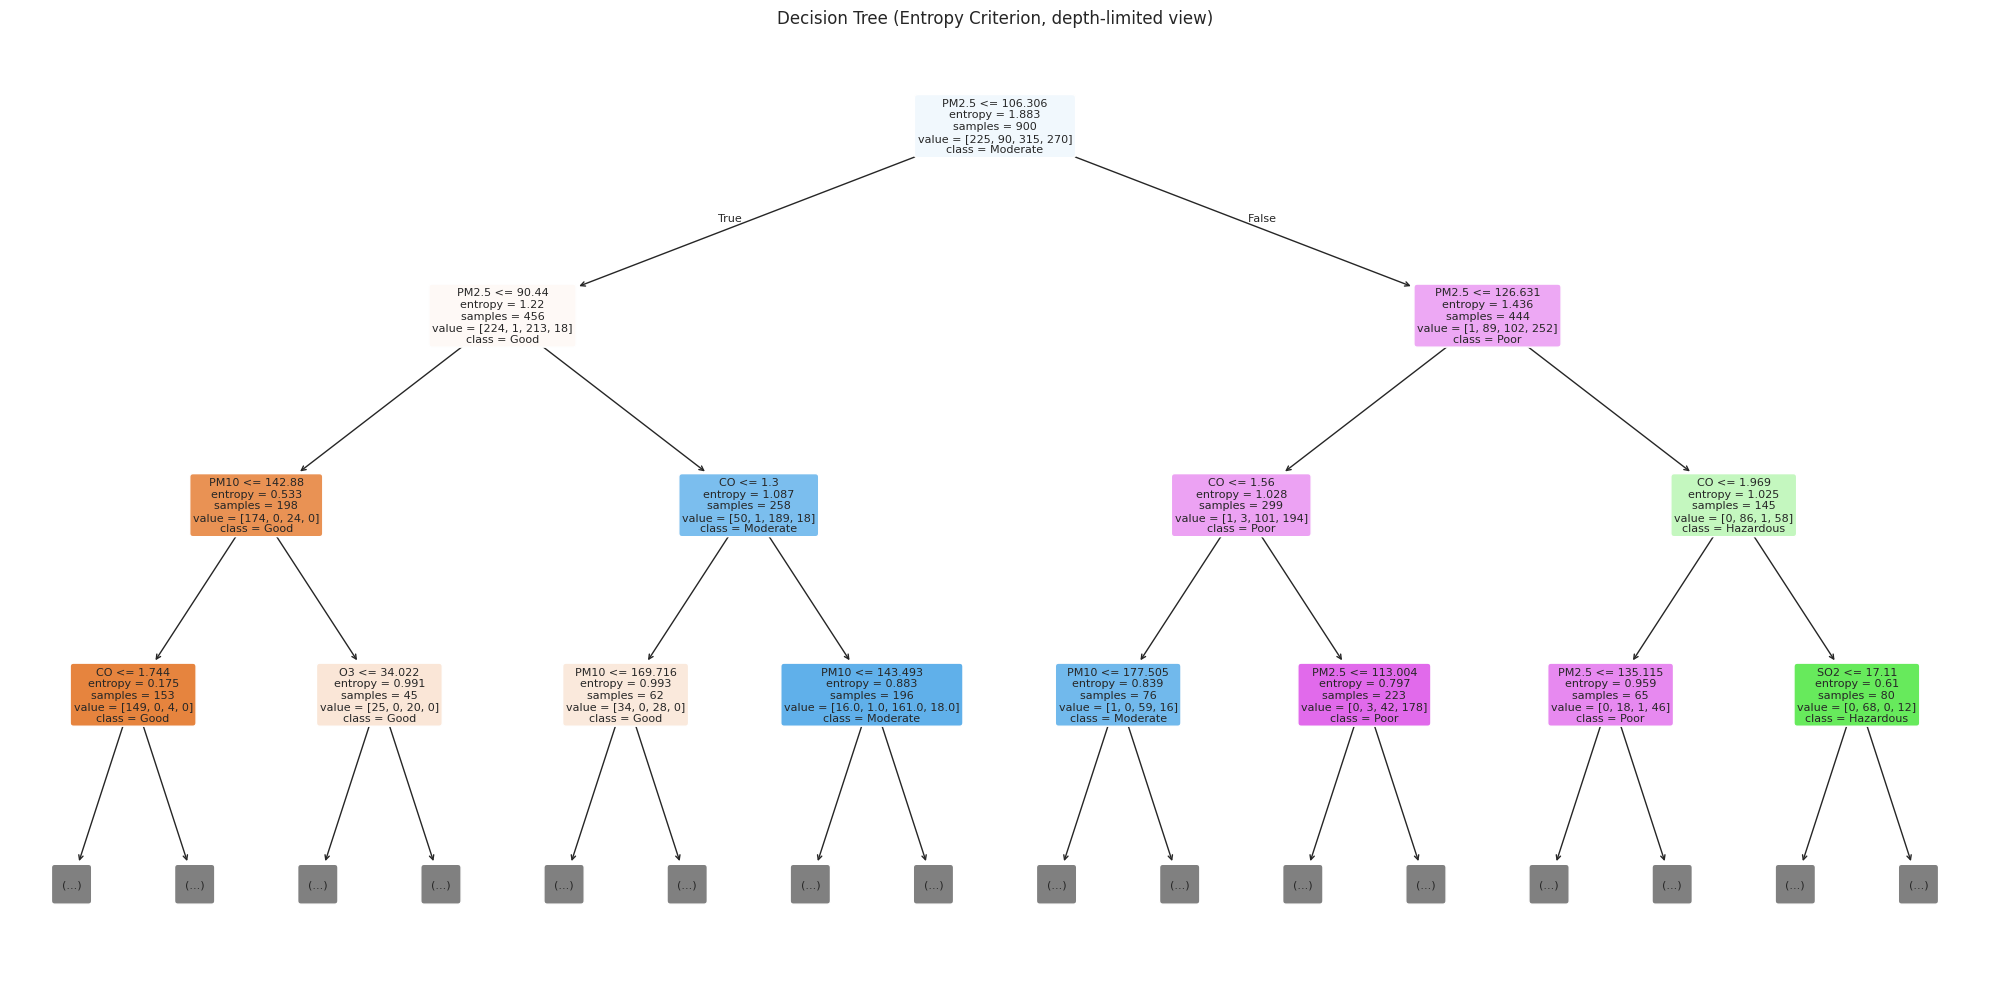

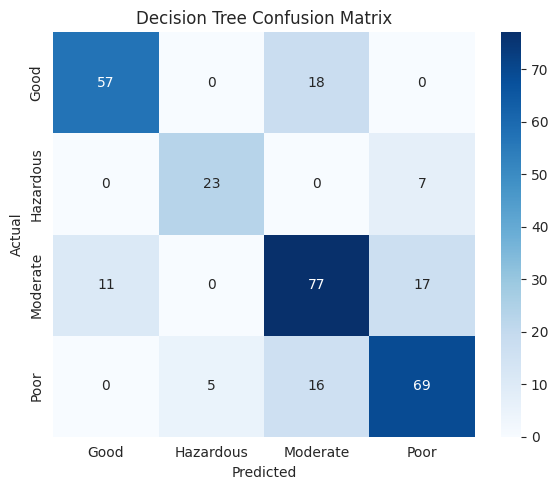

In [5]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("data/air_quality_cleaned.csv")
features = ["PM2.5","PM10","NO2","SO2","CO","O3","Temperature","Humidity","WindSpeed","Pressure"]
X = df[features]
y = df["AQI_Category"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# ---- Manual Information Gain illustration for the ROOT split ----
def entropy(labels):
    vals, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log2(p))

root_entropy = entropy(y_train)
print(f"Entropy of full training set (root) = {root_entropy:.4f} bits")

def info_gain_numeric(feat_col, y, thresholds=5):
    vals = np.unique(np.quantile(feat_col, np.linspace(0.1,0.9,thresholds)))
    best_gain, best_t = -1, None
    for t in vals:
        left = y[feat_col <= t]; right = y[feat_col > t]
        if len(left)==0 or len(right)==0: continue
        w = len(left)/len(y)
        gain = entropy(y) - (w*entropy(left) + (1-w)*entropy(right))
        if gain > best_gain:
            best_gain, best_t = gain, t
    return best_gain, best_t

print("\nInformation Gain per attribute (best threshold split):")
ig_results = {}
for f in features:
    g, t = info_gain_numeric(X_train[f].values, y_train.values)
    ig_results[f] = (g, t)
    print(f"  {f:12s}: IG = {g:.4f}  (best threshold ~ {t:.2f})")

best_feat = max(ig_results, key=lambda k: ig_results[k][0])
print(f"\n=> Root attribute selected by Information Gain: {best_feat}")

# ---- Train sklearn Decision Tree (uses Gini by default; also fit entropy variant) ----
dt_gini = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42)
dt_gini.fit(X_train, y_train)
pred_gini = dt_gini.predict(X_test)

dt_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
dt_entropy.fit(X_train, y_train)
pred_entropy = dt_entropy.predict(X_test)

print("\n=== Decision Tree (Gini) ===")
print("Accuracy:", accuracy_score(y_test, pred_gini))
print(classification_report(y_test, pred_gini))

print("=== Decision Tree (Entropy / Information Gain) ===")
print("Accuracy:", accuracy_score(y_test, pred_entropy))
print(classification_report(y_test, pred_entropy))

print("\nFeature importances (entropy tree):")
for f, imp in sorted(zip(features, dt_entropy.feature_importances_), key=lambda x:-x[1]):
    print(f"  {f:12s}: {imp:.4f}")

# Visualize tree
plt.figure(figsize=(20,10))
plot_tree(dt_entropy, feature_names=features, class_names=dt_entropy.classes_,
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title("Decision Tree (Entropy Criterion, depth-limited view)")
plt.tight_layout(); plt.savefig("figs/07_decision_tree.png", dpi=140); plt.show()

# Confusion matrix
import seaborn as sns
cm = confusion_matrix(y_test, pred_entropy, labels=dt_entropy.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=dt_entropy.classes_, yticklabels=dt_entropy.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Decision Tree Confusion Matrix")
plt.tight_layout(); plt.savefig("figs/08_dt_confusion_matrix.png", dpi=140); plt.show()

import json
with open("data/q3_results.json","w") as f:
    json.dump({
        "root_entropy": root_entropy,
        "info_gain": {k: v[0] for k,v in ig_results.items()},
        "root_attribute": best_feat,
        "accuracy_gini": accuracy_score(y_test, pred_gini),
        "accuracy_entropy": accuracy_score(y_test, pred_entropy),
    }, f, indent=2)

---
# Question 4 — Bayesian Classification

Derives **Maximum Likelihood Estimates** (mean, std) of class-conditional Gaussians, walks through a manual **Bayes'-theorem** calculation for one test sample, then trains a full Gaussian Naive Bayes classifier on all features.

=== MLE of Gaussian parameters (mean, std) per class, feature=PM2.5 ===
  Class=Good      : mu_MLE=81.87, sigma_MLE=12.25, n=225
  Class=Hazardous : mu_MLE=139.62, sigma_MLE=10.51, n=90
  Class=Moderate  : mu_MLE=102.73, sigma_MLE=8.47, n=315
  Class=Poor      : mu_MLE=119.21, sigma_MLE=8.91, n=270

Prior probabilities P(Class) [MLE = relative frequency]:
AQI_Category
Moderate     0.35
Poor         0.30
Good         0.25
Hazardous    0.10
Name: proportion, dtype: float64

--- Manual Bayes'-theorem demo for one sample (PM2.5=91.30, true class=Moderate) ---
  P(Good|PM2.5) = P(PM2.5|Good)*P(Good) / P(PM2.5) = 0.02421*0.250/0.01278 = 0.4735
  P(Hazardous|PM2.5) = P(PM2.5|Hazardous)*P(Hazardous) / P(PM2.5) = 0.00000*0.100/0.01278 = 0.0000
  P(Moderate|PM2.5) = P(PM2.5|Moderate)*P(Moderate) / P(PM2.5) = 0.01895*0.350/0.01278 = 0.5187
  P(Poor|PM2.5) = P(PM2.5|Poor)*P(Poor) / P(PM2.5) = 0.00033*0.300/0.01278 = 0.0078
  => Manual Bayes prediction (PM2.5-only): Moderate  (true: Moderate)

=== 

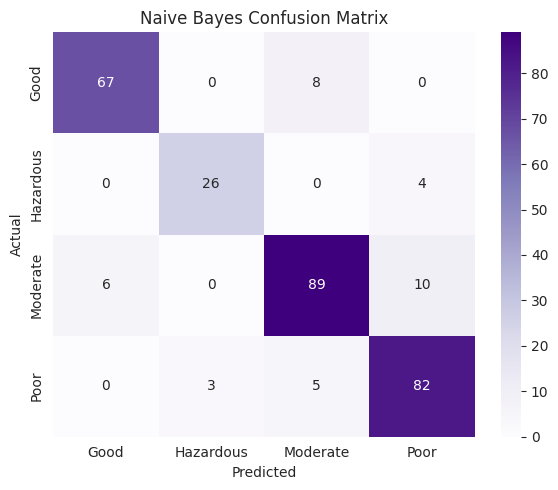

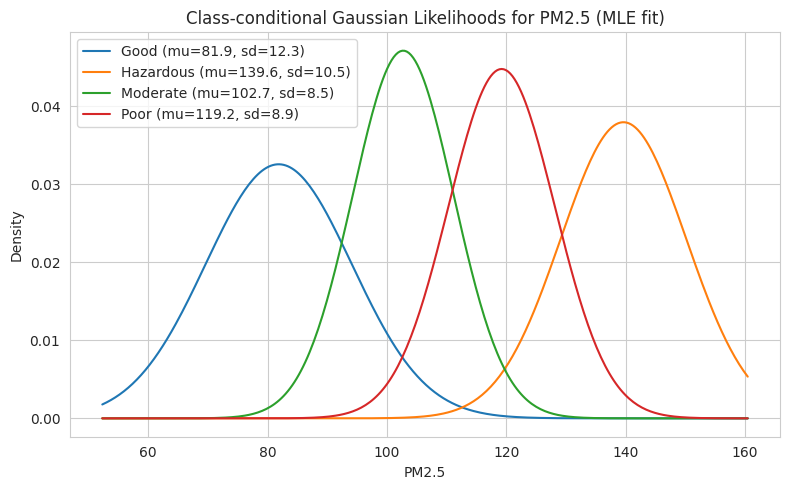

In [6]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("data/air_quality_cleaned.csv")
features = ["PM2.5","PM10","NO2","SO2","CO","O3","Temperature","Humidity","WindSpeed","Pressure"]
X = df[features]; y = df["AQI_Category"]
classes = sorted(y.unique())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# ---- Maximum Likelihood Estimation of Gaussian parameters per class for PM2.5 ----
print("=== MLE of Gaussian parameters (mean, std) per class, feature=PM2.5 ===")
mle_params = {}
for c in classes:
    vals = X_train.loc[y_train == c, "PM2.5"]
    mu_mle = vals.mean()          # MLE estimator of mean
    sigma_mle = vals.std(ddof=0)  # MLE estimator of std (biased, /N)
    mle_params[c] = (mu_mle, sigma_mle)
    print(f"  Class={c:10s}: mu_MLE={mu_mle:.2f}, sigma_MLE={sigma_mle:.2f}, n={len(vals)}")

# Prior probabilities P(class) via MLE (relative frequency)
priors = y_train.value_counts(normalize=True)
print("\nPrior probabilities P(Class) [MLE = relative frequency]:")
print(priors)

def gaussian_pdf(x, mu, sigma):
    return (1.0/(np.sqrt(2*np.pi)*sigma)) * np.exp(-0.5*((x-mu)/sigma)**2)

# Manual Bayes' theorem demo for a single test sample using ONLY PM2.5 feature
sample = X_test.iloc[0]
true_label = y_test.iloc[0]
print(f"\n--- Manual Bayes'-theorem demo for one sample (PM2.5={sample['PM2.5']:.2f}, true class={true_label}) ---")
posteriors = {}
evidence = 0
likelihoods = {}
for c in classes:
    mu, sigma = mle_params[c]
    like = gaussian_pdf(sample["PM2.5"], mu, sigma)
    likelihoods[c] = like
    evidence += like * priors[c]
for c in classes:
    post = (likelihoods[c] * priors[c]) / evidence
    posteriors[c] = post
    print(f"  P({c}|PM2.5) = P(PM2.5|{c})*P({c}) / P(PM2.5) = {likelihoods[c]:.5f}*{priors[c]:.3f}/{evidence:.5f} = {post:.4f}")
pred_manual = max(posteriors, key=posteriors.get)
print(f"  => Manual Bayes prediction (PM2.5-only): {pred_manual}  (true: {true_label})")

# ---- Full Gaussian Naive Bayes classifier (all features) ----
gnb = GaussianNB()
gnb.fit(X_train, y_train)
pred = gnb.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"\n=== Gaussian Naive Bayes (all 10 features) ===\nAccuracy: {acc:.4f}")
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred, labels=gnb.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=gnb.classes_, yticklabels=gnb.classes_)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Naive Bayes Confusion Matrix")
plt.tight_layout(); plt.savefig("figs/09_nb_confusion_matrix.png", dpi=140); plt.show()

# Plot class-conditional Gaussians for PM2.5
plt.figure(figsize=(8,5))
xs = np.linspace(X["PM2.5"].min(), X["PM2.5"].max(), 300)
for c in classes:
    mu, sigma = mle_params[c]
    plt.plot(xs, gaussian_pdf(xs, mu, sigma), label=f"{c} (mu={mu:.1f}, sd={sigma:.1f})")
plt.title("Class-conditional Gaussian Likelihoods for PM2.5 (MLE fit)")
plt.xlabel("PM2.5"); plt.ylabel("Density"); plt.legend()
plt.tight_layout(); plt.savefig("figs/10_bayes_gaussian_pm25.png", dpi=140); plt.show()

import json
with open("data/q4_results.json","w") as f:
    json.dump({"accuracy_gnb": acc, "mle_params": {k: list(v) for k,v in mle_params.items()},
               "priors": priors.to_dict()}, f, indent=2)

---
# Question 5 — K-Nearest Neighbors (from first principles)

A KNN classifier implemented from scratch (Euclidean distance + majority vote, no sklearn classifier used). Sweeps K = 1..25 and plots the validation curve to select the best K.

=== KNN from scratch: testing K = 1..25 ===
  K= 1  Accuracy=0.7733
  K= 2  Accuracy=0.7733
  K= 3  Accuracy=0.7833
  K= 4  Accuracy=0.8100
  K= 5  Accuracy=0.7933
  K= 6  Accuracy=0.8000
  K= 7  Accuracy=0.8133
  K= 8  Accuracy=0.8267
  K= 9  Accuracy=0.8333
  K=10  Accuracy=0.8567
  K=11  Accuracy=0.8667
  K=12  Accuracy=0.8500
  K=13  Accuracy=0.8733
  K=14  Accuracy=0.8800
  K=15  Accuracy=0.8867
  K=16  Accuracy=0.8733
  K=17  Accuracy=0.8600
  K=18  Accuracy=0.8567
  K=19  Accuracy=0.8500
  K=20  Accuracy=0.8700
  K=21  Accuracy=0.8633
  K=22  Accuracy=0.8800
  K=23  Accuracy=0.8633
  K=24  Accuracy=0.8667
  K=25  Accuracy=0.8633

Best K = 15 with accuracy = 0.8867

=== KNN (K=15) detailed report ===
              precision    recall  f1-score   support

        Good       0.98      0.83      0.90        75
   Hazardous       1.00      0.73      0.85        30
    Moderate       0.84      0.93      0.88       105
        Poor       0.86      0.93      0.89        90

    accuracy

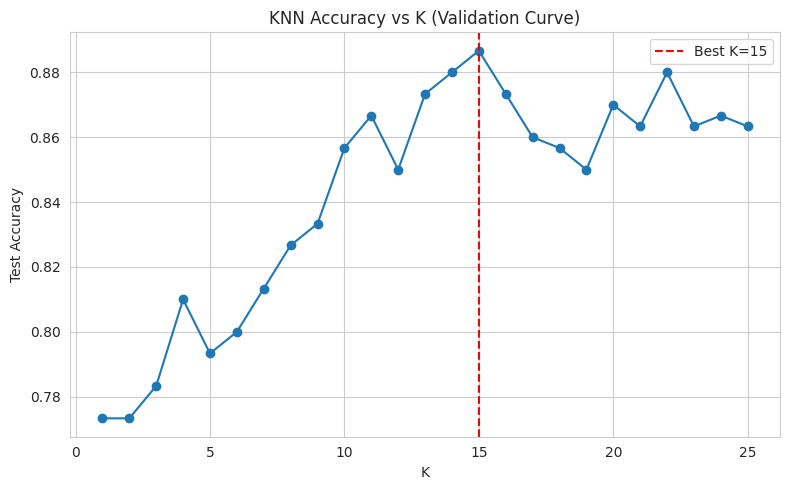

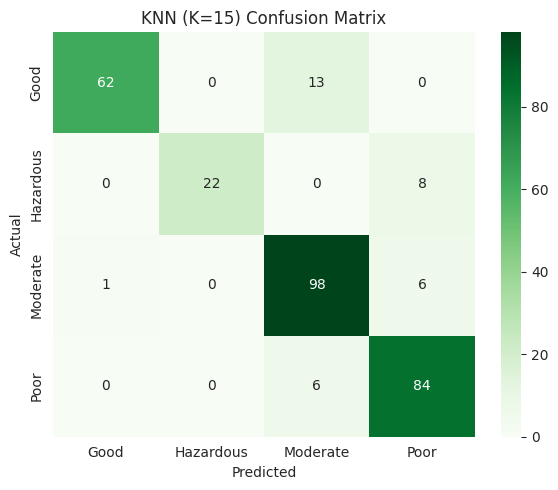

In [7]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import Counter

df = pd.read_csv("data/air_quality_cleaned.csv")
features = ["PM2.5","PM10","NO2","SO2","CO","O3","Temperature","Humidity","WindSpeed","Pressure"]
X = df[features].values
y = df["AQI_Category"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

class KNNScratch:
    """K-Nearest Neighbors implemented from first principles (Euclidean distance)."""
    def __init__(self, k=5):
        self.k = k
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self
    def _predict_one(self, x):
        dists = np.sqrt(np.sum((self.X_train - x)**2, axis=1))  # Euclidean distance
        nn_idx = np.argsort(dists)[:self.k]
        nn_labels = self.y_train[nn_idx]
        vote = Counter(nn_labels).most_common(1)[0][0]
        return vote
    def predict(self, X):
        return np.array([self._predict_one(x) for x in X])

print("=== KNN from scratch: testing K = 1..25 ===")
ks = list(range(1, 26))
accs = []
for k in ks:
    knn = KNNScratch(k=k).fit(X_train_s, y_train)
    pred = knn.predict(X_test_s)
    acc = accuracy_score(y_test, pred)
    accs.append(acc)
    print(f"  K={k:2d}  Accuracy={acc:.4f}")

best_k = ks[int(np.argmax(accs))]
print(f"\nBest K = {best_k} with accuracy = {max(accs):.4f}")

best_knn = KNNScratch(k=best_k).fit(X_train_s, y_train)
best_pred = best_knn.predict(X_test_s)
print(f"\n=== KNN (K={best_k}) detailed report ===")
print(classification_report(y_test, best_pred))

# Plot accuracy vs K (validation curve)
plt.figure(figsize=(8,5))
plt.plot(ks, accs, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title("KNN Accuracy vs K (Validation Curve)")
plt.xlabel("K"); plt.ylabel("Test Accuracy"); plt.legend()
plt.tight_layout(); plt.savefig("figs/11_knn_k_validation_curve.png", dpi=140); plt.show()

import seaborn as sns
labels_order = sorted(set(y_test))
cm = confusion_matrix(y_test, best_pred, labels=labels_order)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"KNN (K={best_k}) Confusion Matrix")
plt.tight_layout(); plt.savefig("figs/12_knn_confusion_matrix.png", dpi=140); plt.show()

import json
with open("data/q5_results.json","w") as f:
    json.dump({"ks": ks, "accs": accs, "best_k": best_k, "best_acc": max(accs)}, f, indent=2)

---
# Question 6 — Locally Weighted Regression (from first principles)

Implements LWR from scratch using a Gaussian kernel and the closed-form weighted least-squares solution, predicts PM2.5 from Wind Speed, studies the effect of the bandwidth parameter tau, and compares against global Linear Regression.

=== Locally Weighted Regression: effect of bandwidth tau ===
  tau= 0.3  MAE=15.234  RMSE=19.154  R2= 0.063
  tau= 0.7  MAE=15.164  RMSE=19.022  R2= 0.076
  tau= 1.5  MAE=15.158  RMSE=18.967  R2= 0.081
  tau= 3.0  MAE=15.146  RMSE=18.969  R2= 0.081
  tau= 6.0  MAE=15.144  RMSE=18.970  R2= 0.081

Best tau (lowest RMSE) = 1.5

=== Global Linear Regression (comparison) ===
MAE=15.146  RMSE=18.971  R2=0.081


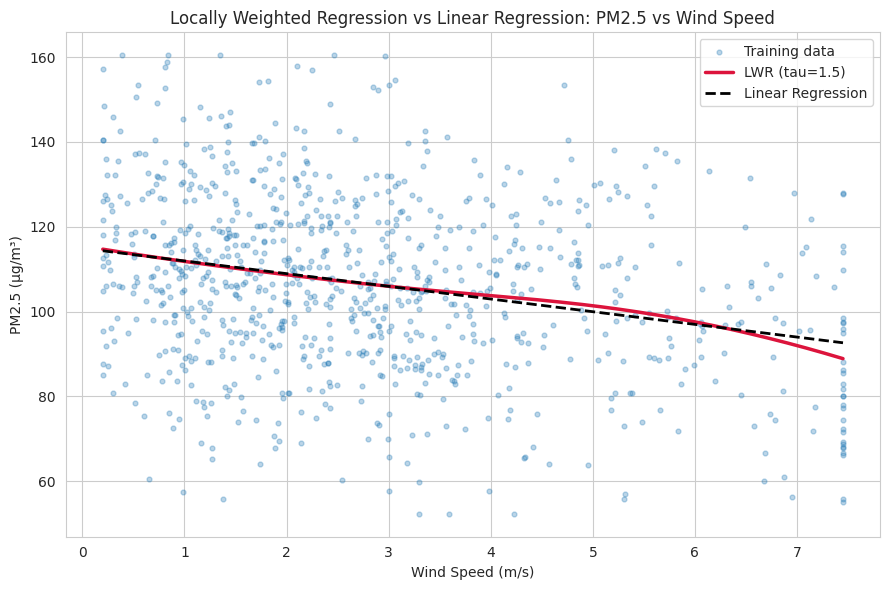

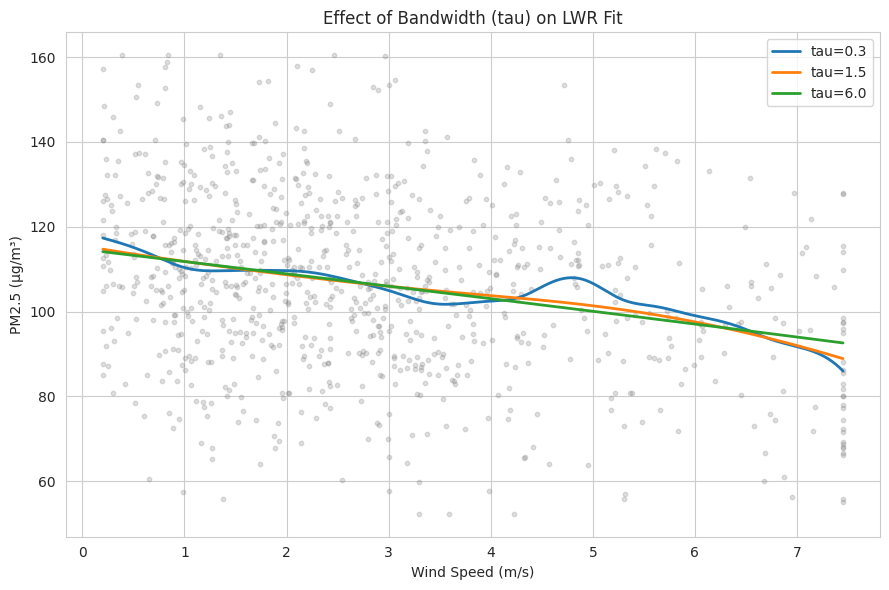

In [8]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/air_quality_cleaned.csv")
# Predict PM2.5 from WindSpeed (clear inverse nonlinear-ish relationship) for interpretable 1D LWR,
# then also do a multi-feature version.
df_sorted = df.sort_values("WindSpeed").reset_index(drop=True)
X1 = df_sorted["WindSpeed"].values.reshape(-1,1)
y1 = df_sorted["PM2.5"].values

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.25, random_state=42)

def lwr_predict(X_train, y_train, x_query, tau):
    """Locally Weighted Regression prediction at a single query point x_query.
    Uses Gaussian kernel weights and closed-form weighted least squares:
        theta = (X^T W X)^-1 X^T W y
    """
    m = X_train.shape[0]
    Xb = np.hstack([np.ones((m,1)), X_train])              # add bias term
    diffs = X_train[:,0] - x_query
    w = np.exp(-(diffs**2) / (2*tau**2))                    # Gaussian kernel weights
    W = np.diag(w)
    xq = np.array([1, x_query])
    try:
        theta = np.linalg.pinv(Xb.T @ W @ Xb) @ (Xb.T @ W @ y_train)
    except np.linalg.LinAlgError:
        theta = np.zeros(2)
    return xq @ theta

def lwr_batch(X_train, y_train, X_query, tau):
    return np.array([lwr_predict(X_train, y_train, xq[0], tau) for xq in X_query])

print("=== Locally Weighted Regression: effect of bandwidth tau ===")
taus = [0.3, 0.7, 1.5, 3.0, 6.0]
results = {}
for tau in taus:
    pred = lwr_batch(X1_train, y1_train, X1_test, tau)
    mae = mean_absolute_error(y1_test, pred)
    rmse = np.sqrt(mean_squared_error(y1_test, pred))
    r2 = r2_score(y1_test, pred)
    results[tau] = (mae, rmse, r2)
    print(f"  tau={tau:4.1f}  MAE={mae:6.3f}  RMSE={rmse:6.3f}  R2={r2:6.3f}")

best_tau = min(results, key=lambda t: results[t][1])
print(f"\nBest tau (lowest RMSE) = {best_tau}")

# Compare with standard Linear Regression (global model)
lr = LinearRegression().fit(X1_train, y1_train)
lr_pred = lr.predict(X1_test)
lr_mae = mean_absolute_error(y1_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y1_test, lr_pred))
lr_r2 = r2_score(y1_test, lr_pred)
print(f"\n=== Global Linear Regression (comparison) ===\nMAE={lr_mae:.3f}  RMSE={lr_rmse:.3f}  R2={lr_r2:.3f}")

# Plot LWR fit curve (best tau) vs Linear Regression vs actual data
xs_plot = np.linspace(X1.min(), X1.max(), 200).reshape(-1,1)
lwr_curve = lwr_batch(X1_train, y1_train, xs_plot, best_tau)
lr_curve = lr.predict(xs_plot)

plt.figure(figsize=(9,6))
plt.scatter(X1_train, y1_train, s=12, alpha=0.3, label="Training data")
plt.plot(xs_plot, lwr_curve, color="crimson", linewidth=2.5, label=f"LWR (tau={best_tau})")
plt.plot(xs_plot, lr_curve, color="black", linestyle="--", linewidth=2, label="Linear Regression")
plt.xlabel("Wind Speed (m/s)"); plt.ylabel("PM2.5 (µg/m³)")
plt.title("Locally Weighted Regression vs Linear Regression: PM2.5 vs Wind Speed")
plt.legend()
plt.tight_layout(); plt.savefig("figs/13_lwr_vs_linear.png", dpi=140); plt.show()

# Plot effect of tau (under/over-fitting)
plt.figure(figsize=(9,6))
plt.scatter(X1_train, y1_train, s=10, alpha=0.25, color="gray")
for tau, style in zip([0.3, 1.5, 6.0], ["-", "-", "-"]):
    curve = lwr_batch(X1_train, y1_train, xs_plot, tau)
    plt.plot(xs_plot, curve, linewidth=2, label=f"tau={tau}")
plt.title("Effect of Bandwidth (tau) on LWR Fit")
plt.xlabel("Wind Speed (m/s)"); plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.tight_layout(); plt.savefig("figs/14_lwr_tau_effect.png", dpi=140); plt.show()

import json
with open("data/q6_results.json","w") as f:
    json.dump({"tau_results": {str(k): v for k,v in results.items()}, "best_tau": best_tau,
               "linear_regression": {"mae": lr_mae, "rmse": lr_rmse, "r2": lr_r2}}, f, indent=2)

---
# Question 7 — Neural Network (MLP) with Back-Propagation (from first principles)

A Multilayer Perceptron (sigmoid hidden layer + softmax output) implemented from scratch with a full forward pass, cross-entropy loss, and manual back-propagation via the chain rule. Includes a small hidden-size / learning-rate hyperparameter sweep.

=== Training MLP (1 hidden layer, sigmoid+softmax, backprop) ===
Architecture: 10 inputs -> 16 hidden (sigmoid) -> 4 outputs (softmax)
  Epoch  150/1500  Cross-Entropy Loss=0.3681
  Epoch  300/1500  Cross-Entropy Loss=0.2464
  Epoch  450/1500  Cross-Entropy Loss=0.1867
  Epoch  600/1500  Cross-Entropy Loss=0.1509
  Epoch  750/1500  Cross-Entropy Loss=0.1271
  Epoch  900/1500  Cross-Entropy Loss=0.1103
  Epoch 1050/1500  Cross-Entropy Loss=0.0979
  Epoch 1200/1500  Cross-Entropy Loss=0.0883
  Epoch 1350/1500  Cross-Entropy Loss=0.0807
  Epoch 1500/1500  Cross-Entropy Loss=0.0744

Train Accuracy: 0.9900
Test  Accuracy: 0.9700

Classification report (test):
              precision    recall  f1-score   support

        Good       0.96      1.00      0.98        75
   Hazardous       0.97      1.00      0.98        30
    Moderate       0.96      0.96      0.96       105
        Poor       0.99      0.94      0.97        90

    accuracy                           0.97       300
   macro av

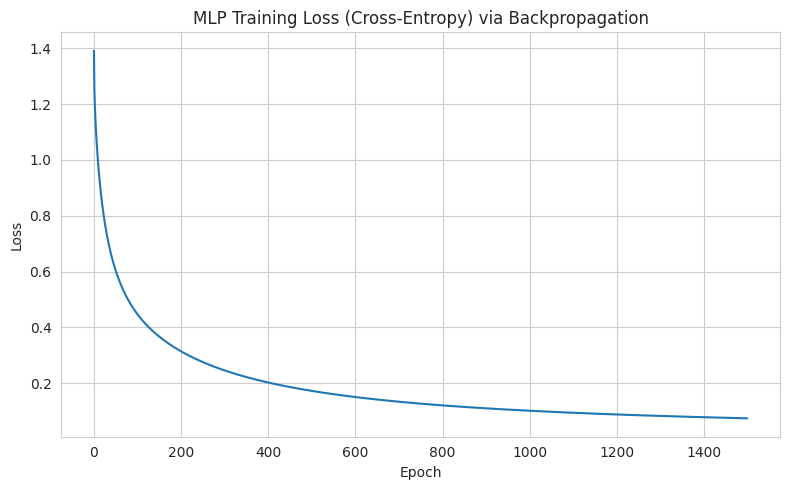

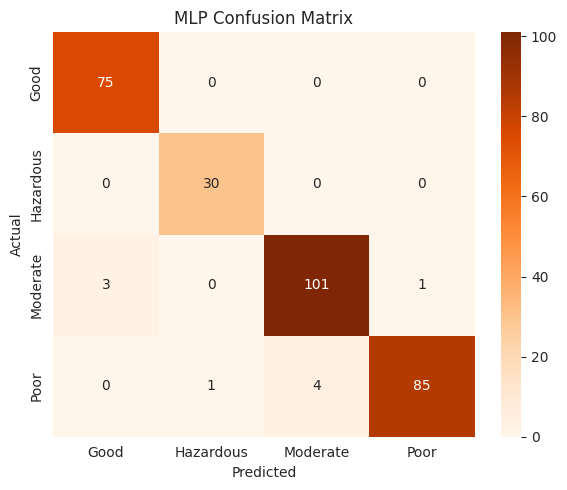

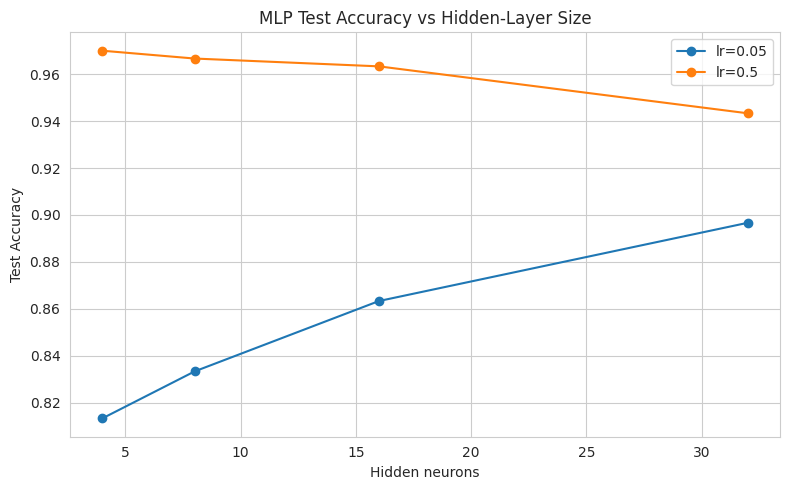

In [9]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("data/air_quality_cleaned.csv")
features = ["PM2.5","PM10","NO2","SO2","CO","O3","Temperature","Humidity","WindSpeed","Pressure"]
X = df[features].values
y_raw = df["AQI_Category"].values

classes = sorted(np.unique(y_raw))
class_to_idx = {c:i for i,c in enumerate(classes)}
y_idx = np.array([class_to_idx[c] for c in y_raw])
n_classes = len(classes)
Y_onehot = np.eye(n_classes)[y_idx]

X_train, X_test, y_train_oh, y_test_oh, y_train_idx, y_test_idx = train_test_split(
    X, Y_onehot, y_idx, test_size=0.25, random_state=42, stratify=y_idx)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

def sigmoid(z): return 1/(1+np.exp(-np.clip(z,-500,500)))
def sigmoid_deriv(a): return a*(1-a)
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=1, keepdims=True)

class MLP:
    """Multilayer Perceptron: input -> hidden(sigmoid) -> output(softmax),
    trained with backpropagation (gradient descent, cross-entropy loss)."""
    def __init__(self, n_in, n_hidden, n_out, lr=0.1, seed=42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2.0/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2.0/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr
        self.loss_history = []

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = softmax(self.z2)
        return self.a2

    def backward(self, X, Y):
        m = X.shape[0]
        # Output layer error (softmax + cross-entropy simplifies to a2 - Y)
        dz2 = (self.a2 - Y) / m
        dW2 = self.a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)
        da1 = dz2 @ self.W2.T
        dz1 = da1 * sigmoid_deriv(self.a1)
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)
        # Gradient descent update
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1

    def train(self, X, Y, epochs=1000, verbose_every=100):
        for e in range(epochs):
            out = self.forward(X)
            loss = -np.mean(np.sum(Y*np.log(out+1e-9), axis=1))
            self.loss_history.append(loss)
            self.backward(X, Y)
            if (e+1) % verbose_every == 0:
                print(f"  Epoch {e+1:4d}/{epochs}  Cross-Entropy Loss={loss:.4f}")

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

print("=== Training MLP (1 hidden layer, sigmoid+softmax, backprop) ===")
print("Architecture: 10 inputs -> 16 hidden (sigmoid) -> 4 outputs (softmax)")
mlp = MLP(n_in=X_train_s.shape[1], n_hidden=16, n_out=n_classes, lr=0.5, seed=42)
mlp.train(X_train_s, y_train_oh, epochs=1500, verbose_every=150)

train_pred = mlp.predict(X_train_s)
test_pred = mlp.predict(X_test_s)
train_acc = accuracy_score(y_train_idx, train_pred)
test_acc = accuracy_score(y_test_idx, test_pred)
print(f"\nTrain Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")
print("\nClassification report (test):")
print(classification_report(y_test_idx, test_pred, target_names=classes))

# Experiment with different hidden sizes / learning rates
print("\n=== Hyperparameter experiments ===")
exp_results = []
for hidden in [4, 8, 16, 32]:
    for lr in [0.05, 0.5]:
        m = MLP(n_in=X_train_s.shape[1], n_hidden=hidden, n_out=n_classes, lr=lr, seed=1)
        m.train(X_train_s, y_train_oh, epochs=800, verbose_every=10000)
        acc = accuracy_score(y_test_idx, m.predict(X_test_s))
        exp_results.append((hidden, lr, acc))
        print(f"  hidden={hidden:3d}  lr={lr:.2f}  test_acc={acc:.4f}")

# Plot training loss curve
plt.figure(figsize=(8,5))
plt.plot(mlp.loss_history)
plt.title("MLP Training Loss (Cross-Entropy) via Backpropagation")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout(); plt.savefig("figs/15_mlp_loss_curve.png", dpi=140); plt.show()

import seaborn as sns
cm = confusion_matrix(y_test_idx, test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("MLP Confusion Matrix")
plt.tight_layout(); plt.savefig("figs/16_mlp_confusion_matrix.png", dpi=140); plt.show()

# Plot hyperparameter comparison
plt.figure(figsize=(8,5))
hiddens = sorted(set(h for h,_,_ in exp_results))
for lr in sorted(set(l for _,l,_ in exp_results)):
    accs_lr = [a for h,l,a in exp_results if l==lr]
    plt.plot(hiddens, accs_lr, marker='o', label=f"lr={lr}")
plt.title("MLP Test Accuracy vs Hidden-Layer Size")
plt.xlabel("Hidden neurons"); plt.ylabel("Test Accuracy"); plt.legend()
plt.tight_layout(); plt.savefig("figs/17_mlp_hyperparam.png", dpi=140); plt.show()

import json
with open("data/q7_results.json","w") as f:
    json.dump({"train_acc": train_acc, "test_acc": test_acc,
               "experiments": exp_results}, f, indent=2)

---
# Question 8 — Genetic Algorithm for Feature Selection

A Genetic Algorithm (binary chromosome = selected features, fitness = accuracy minus a complexity penalty, tournament selection, single-point crossover, bit-flip mutation, elitism) searches for the best feature subset and compares it against the full-feature baseline model.

Baseline (all 10 features) Decision Tree accuracy: 0.8133

=== Genetic Algorithm evolution (feature selection) ===
  Gen  0: best_fitness=0.8087  avg=0.6862  features=['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity', 'Pressure']
  Gen  5: best_fitness=0.8087  avg=0.7794  features=['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3', 'Temperature', 'Humidity', 'Pressure']
  Gen 10: best_fitness=0.8113  avg=0.7980  features=['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Humidity']
  Gen 15: best_fitness=0.8133  avg=0.7988  features=['PM2.5', 'PM10', 'NO2', 'SO2', 'CO']
  Gen 20: best_fitness=0.8133  avg=0.7943  features=['PM2.5', 'PM10', 'NO2', 'SO2', 'CO']
  Gen 25: best_fitness=0.8133  avg=0.7954  features=['PM2.5', 'PM10', 'NO2', 'SO2', 'CO']
  Gen 29: best_fitness=0.8133  avg=0.8032  features=['PM2.5', 'PM10', 'NO2', 'SO2', 'CO']

Best chromosome: [1 1 1 1 1 0 0 0 0 0]
Selected features (5): ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO']
Best fitness (accuracy - penalty): 0.8133

GA-optimi

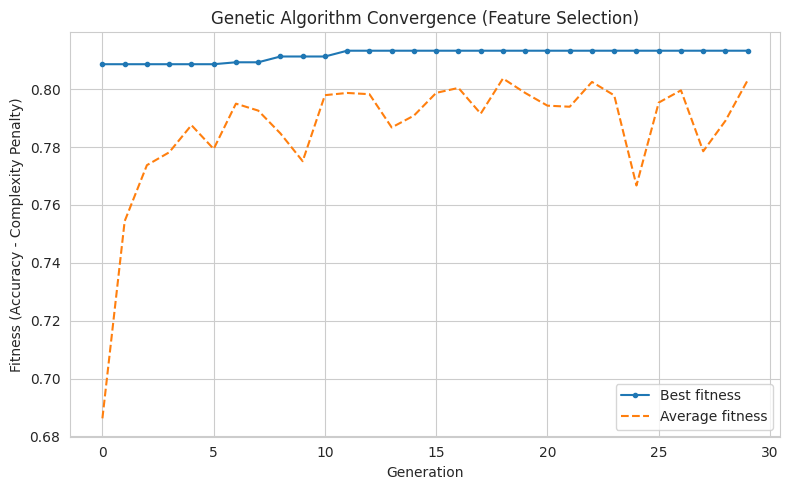

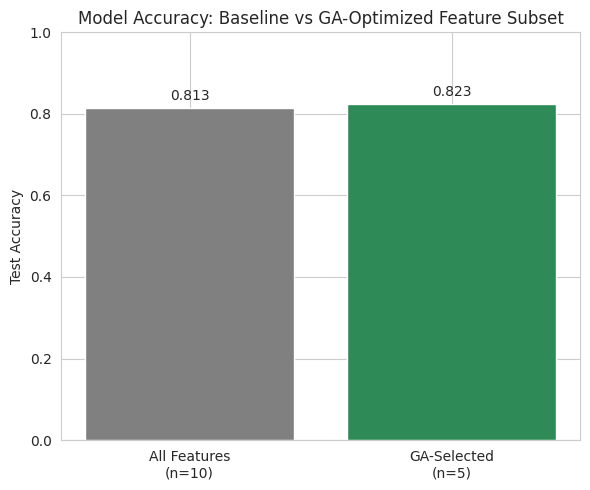

In [10]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data/air_quality_cleaned.csv")
features = ["PM2.5","PM10","NO2","SO2","CO","O3","Temperature","Humidity","WindSpeed","Pressure"]
X = df[features].values
y = df["AQI_Category"].values
n_features = len(features)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

# ---- Baseline: model using ALL features ----
base_clf = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train_s, y_train)
base_acc = accuracy_score(y_test, base_clf.predict(X_test_s))
print(f"Baseline (all {n_features} features) Decision Tree accuracy: {base_acc:.4f}")

# ---- Genetic Algorithm for feature selection ----
# Chromosome: binary vector of length n_features (1 = feature selected)
# Fitness: classification accuracy on validation split, with a small penalty
#          per selected feature to encourage compact feature subsets.
POP_SIZE = 20
GENERATIONS = 30
MUTATION_RATE = 0.08
CROSSOVER_RATE = 0.8
PENALTY = 0.002  # per-feature complexity penalty

rng = np.random.RandomState(7)

def random_chromosome():
    c = rng.randint(0, 2, n_features)
    if c.sum() == 0:
        c[rng.randint(n_features)] = 1
    return c

def fitness(chromosome):
    idx = np.where(chromosome == 1)[0]
    if len(idx) == 0:
        return 0.0
    clf = DecisionTreeClassifier(max_depth=5, random_state=42)
    clf.fit(X_train_s[:, idx], y_train)
    acc = accuracy_score(y_test, clf.predict(X_test_s[:, idx]))
    return acc - PENALTY * len(idx)

def tournament_select(pop, fits, k=3):
    idxs = rng.choice(len(pop), k, replace=False)
    best = idxs[np.argmax([fits[i] for i in idxs])]
    return pop[best].copy()

def crossover(p1, p2):
    if rng.rand() < CROSSOVER_RATE:
        point = rng.randint(1, n_features)
        c1 = np.concatenate([p1[:point], p2[point:]])
        c2 = np.concatenate([p2[:point], p1[point:]])
        return c1, c2
    return p1.copy(), p2.copy()

def mutate(c):
    for i in range(len(c)):
        if rng.rand() < MUTATION_RATE:
            c[i] = 1 - c[i]
    if c.sum() == 0:
        c[rng.randint(n_features)] = 1
    return c

population = [random_chromosome() for _ in range(POP_SIZE)]
best_fitness_history = []
avg_fitness_history = []
best_chromosome, best_fit = None, -np.inf

print("\n=== Genetic Algorithm evolution (feature selection) ===")
for gen in range(GENERATIONS):
    fits = [fitness(c) for c in population]
    gen_best_idx = int(np.argmax(fits))
    if fits[gen_best_idx] > best_fit:
        best_fit = fits[gen_best_idx]
        best_chromosome = population[gen_best_idx].copy()
    best_fitness_history.append(fits[gen_best_idx])
    avg_fitness_history.append(np.mean(fits))
    if gen % 5 == 0 or gen == GENERATIONS-1:
        sel = [features[i] for i,b in enumerate(population[gen_best_idx]) if b]
        print(f"  Gen {gen:2d}: best_fitness={fits[gen_best_idx]:.4f}  avg={np.mean(fits):.4f}  features={sel}")

    # New generation: elitism (keep best) + crossover + mutation
    new_pop = [population[gen_best_idx].copy()]
    while len(new_pop) < POP_SIZE:
        p1 = tournament_select(population, fits)
        p2 = tournament_select(population, fits)
        c1, c2 = crossover(p1, p2)
        new_pop.append(mutate(c1))
        if len(new_pop) < POP_SIZE:
            new_pop.append(mutate(c2))
    population = new_pop

selected_features = [features[i] for i,b in enumerate(best_chromosome) if b]
print(f"\nBest chromosome: {best_chromosome}")
print(f"Selected features ({len(selected_features)}): {selected_features}")
print(f"Best fitness (accuracy - penalty): {best_fit:.4f}")

idx = np.where(best_chromosome == 1)[0]
ga_clf = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train_s[:, idx], y_train)
ga_acc = accuracy_score(y_test, ga_clf.predict(X_test_s[:, idx]))
print(f"\nGA-optimized model accuracy (using {len(idx)} features): {ga_acc:.4f}")
print(f"Baseline model accuracy (using {n_features} features):     {base_acc:.4f}")

# Plot GA convergence
plt.figure(figsize=(8,5))
plt.plot(best_fitness_history, label="Best fitness", marker='o', markersize=3)
plt.plot(avg_fitness_history, label="Average fitness", linestyle='--')
plt.title("Genetic Algorithm Convergence (Feature Selection)")
plt.xlabel("Generation"); plt.ylabel("Fitness (Accuracy - Complexity Penalty)")
plt.legend()
plt.tight_layout(); plt.savefig("figs/18_ga_convergence.png", dpi=140); plt.show()

# Bar chart comparing baseline vs GA-optimized
plt.figure(figsize=(6,5))
plt.bar(["All Features\n(n=%d)"%n_features, "GA-Selected\n(n=%d)"%len(idx)], [base_acc, ga_acc], color=["gray","seagreen"])
plt.ylim(0,1)
plt.title("Model Accuracy: Baseline vs GA-Optimized Feature Subset")
plt.ylabel("Test Accuracy")
for i,v in enumerate([base_acc, ga_acc]):
    plt.text(i, v+0.02, f"{v:.3f}", ha='center')
plt.tight_layout(); plt.savefig("figs/19_ga_vs_baseline.png", dpi=140); plt.show()

import json
with open("data/q8_results.json","w") as f:
    json.dump({"selected_features": selected_features, "ga_accuracy": ga_acc,
               "baseline_accuracy": base_acc, "best_fitness": best_fit}, f, indent=2)

---
# Question 9 — Model Evaluation and Comparison

Evaluates Decision Tree, Naive Bayes, KNN and MLP on the same test split using Accuracy, macro-Precision, macro-Recall and macro-F1, plus a scalability (training-time vs dataset-size) analysis.

Decision Tree                Acc=0.7533  Prec=0.7738  Rec=0.7567  F1=0.7643
Naive Bayes                  Acc=0.8800  Prec=0.8853  Rec=0.8797  F1=0.8821
KNN (K=15)                   Acc=0.8867  Prec=0.9197  Rec=0.8567  F1=0.8803
MLP (sklearn, 16 hidden)     Acc=0.9567  Prec=0.9495  Rec=0.9588  F1=0.9538

=== Comparison Table ===
                   Model  Accuracy  Precision(macro)  Recall(macro)  F1(macro)
           Decision Tree    0.7533            0.7738         0.7567     0.7643
             Naive Bayes    0.8800            0.8853         0.8797     0.8821
              KNN (K=15)    0.8867            0.9197         0.8567     0.8803
MLP (sklearn, 16 hidden)    0.9567            0.9495         0.9588     0.9538

Scratch KNN best K=15 test accuracy=0.8867
Scratch MLP (16 hidden) test accuracy=0.9700
GA-optimized DT (features=['PM2.5', 'PM10', 'NO2', 'SO2', 'CO']) accuracy=0.8233
LWR (regression, tau=1.5) RMSE=18.967, MAE=15.158


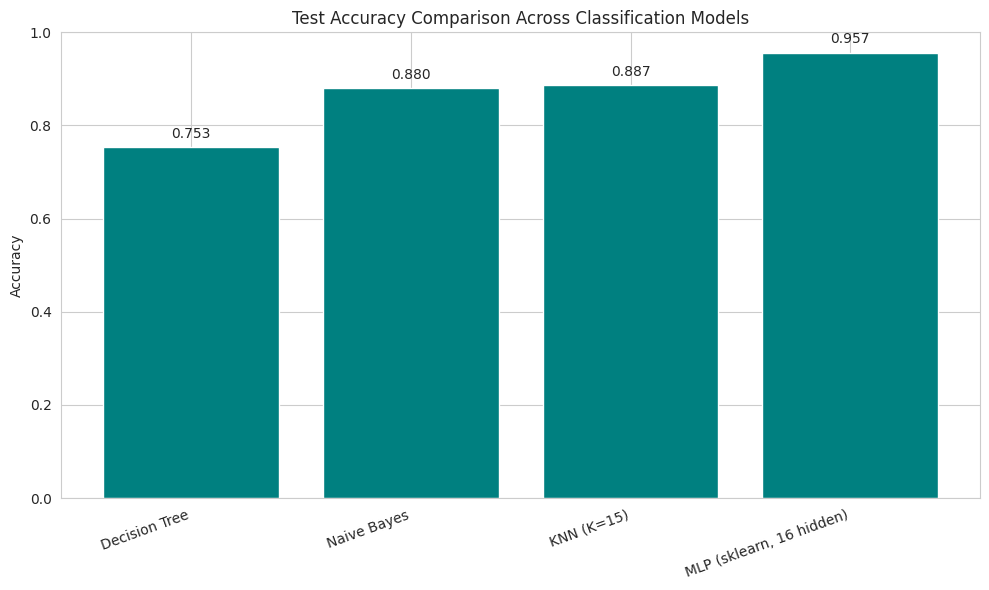

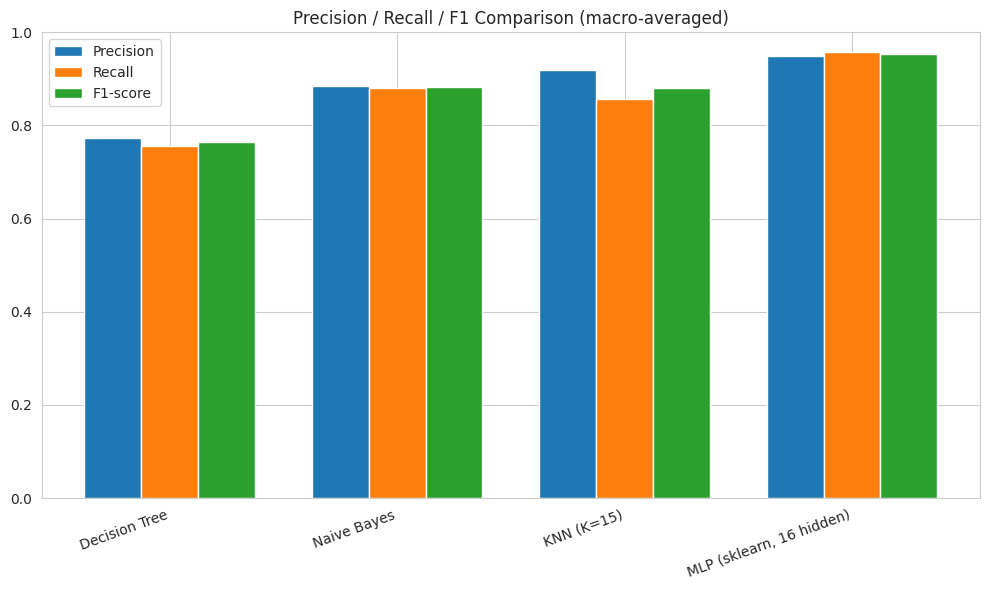

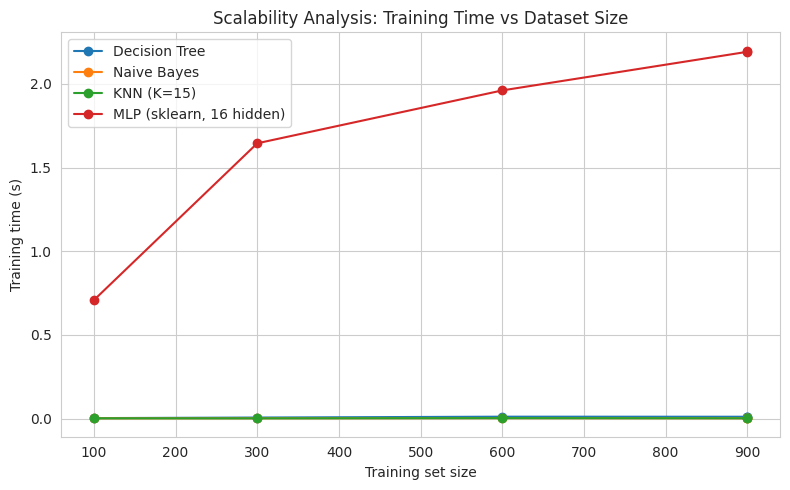


Scalability (training time in seconds):
  Decision Tree               : ['0.0030', '0.0064', '0.0115', '0.0112', '0.0114']
  Naive Bayes                 : ['0.0018', '0.0021', '0.0029', '0.0022', '0.0026']
  KNN (K=15)                  : ['0.0017', '0.0016', '0.0029', '0.0020', '0.0022']
  MLP (sklearn, 16 hidden)    : ['0.7082', '1.6450', '1.9609', '2.1916', '2.1981']


In [11]:
import numpy as np, pandas as pd, json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv("data/air_quality_cleaned.csv")
features = ["PM2.5","PM10","NO2","SO2","CO","O3","Temperature","Humidity","WindSpeed","Pressure"]
X = df[features].values; y = df["AQI_Category"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

models = {
    "Decision Tree": DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN (K=15)": KNeighborsClassifier(n_neighbors=15),
    "MLP (sklearn, 16 hidden)": MLPClassifier(hidden_layer_sizes=(16,), max_iter=2000, random_state=42),
}

rows = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, average="macro", zero_division=0)
    rec = recall_score(y_test, pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, pred, average="macro", zero_division=0)
    rows.append({"Model": name, "Accuracy": acc, "Precision(macro)": prec,
                 "Recall(macro)": rec, "F1(macro)": f1})
    print(f"{name:28s} Acc={acc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  F1={f1:.4f}")

# Include GA-optimized DT and best-K KNN from earlier steps + LWR regression metrics
with open("data/q5_results.json") as f: q5 = json.load(f)
with open("data/q6_results.json") as f: q6 = json.load(f)
with open("data/q7_results.json") as f: q7 = json.load(f)
with open("data/q8_results.json") as f: q8 = json.load(f)

results_df = pd.DataFrame(rows)
results_df.to_csv("data/model_comparison.csv", index=False)
print("\n=== Comparison Table ===")
print(results_df.round(4).to_string(index=False))

print(f"\nScratch KNN best K={q5['best_k']} test accuracy={q5['best_acc']:.4f}")
print(f"Scratch MLP (16 hidden) test accuracy={q7['test_acc']:.4f}")
print(f"GA-optimized DT (features={q8['selected_features']}) accuracy={q8['ga_accuracy']:.4f}")
print(f"LWR (regression, tau={q6['best_tau']}) RMSE={q6['tau_results'][str(q6['best_tau'])][1]:.3f}, "
      f"MAE={q6['tau_results'][str(q6['best_tau'])][0]:.3f}")

# Bar chart comparing accuracy across models
plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["Accuracy"], color="teal")
plt.ylim(0,1); plt.xticks(rotation=20, ha="right")
plt.title("Test Accuracy Comparison Across Classification Models")
plt.ylabel("Accuracy")
for i,v in enumerate(results_df["Accuracy"]):
    plt.text(i, v+0.02, f"{v:.3f}", ha="center")
plt.tight_layout(); plt.savefig("figs/20_model_comparison_accuracy.png", dpi=140); plt.show()

# Grouped bar: precision/recall/F1
plt.figure(figsize=(10,6))
x = np.arange(len(results_df))
w = 0.25
plt.bar(x-w, results_df["Precision(macro)"], width=w, label="Precision")
plt.bar(x, results_df["Recall(macro)"], width=w, label="Recall")
plt.bar(x+w, results_df["F1(macro)"], width=w, label="F1-score")
plt.xticks(x, results_df["Model"], rotation=20, ha="right")
plt.ylim(0,1); plt.legend()
plt.title("Precision / Recall / F1 Comparison (macro-averaged)")
plt.tight_layout(); plt.savefig("figs/21_model_comparison_prf.png", dpi=140); plt.show()

# Scalability analysis: training time vs dataset size for each model
import time
sizes = [100, 300, 600, 900, len(X_train_s)]
scal_results = {name: [] for name in models}
for size in sizes:
    Xs, ys = X_train_s[:size], y_train[:size]
    for name, model in models.items():
        m2 = type(model)(**model.get_params())
        t0 = time.time()
        m2.fit(Xs, ys)
        scal_results[name].append(time.time()-t0)

plt.figure(figsize=(8,5))
for name, times in scal_results.items():
    plt.plot(sizes, times, marker='o', label=name)
plt.title("Scalability Analysis: Training Time vs Dataset Size")
plt.xlabel("Training set size"); plt.ylabel("Training time (s)")
plt.legend()
plt.tight_layout(); plt.savefig("figs/22_scalability_analysis.png", dpi=140); plt.show()

print("\nScalability (training time in seconds):")
for name, times in scal_results.items():
    print(f"  {name:28s}: {['%.4f'%t for t in times]}")

---
# Question 10 — Integrated Urban Air-Quality Warning System

Wraps the best-performing model (MLP) in a single `urban_air_quality_warning_system()` function that takes raw sensor readings and returns a predicted AQI category, confidence score, and a plain-language health recommendation. Demonstrated on 4 representative scenarios from clean to hazardous.

=== Integrated Urban Air-Quality Warning System: Demo ===

Scenario: Clean windy day
  Inputs: {'PM2.5': 45, 'PM10': 70, 'NO2': 25, 'SO2': 8, 'CO': 0.5, 'O3': 40, 'Temperature': 28, 'Humidity': 45, 'WindSpeed': 6.5, 'Pressure': 1015}
  --> Predicted category : Good  (confidence=1.0)
  --> Recommendation     : Air quality is satisfactory. Normal outdoor activities are safe for everyone.

Scenario: Typical urban day
  Inputs: {'PM2.5': 105, 'PM10': 165, 'NO2': 48, 'SO2': 17, 'CO': 1.2, 'O3': 55, 'Temperature': 27, 'Humidity': 55, 'WindSpeed': 2.5, 'Pressure': 1012}
  --> Predicted category : Moderate  (confidence=1.0)
  --> Recommendation     : Acceptable air quality. Unusually sensitive individuals should consider reducing prolonged outdoor exertion.

Scenario: Post-monsoon humid stagnant
  Inputs: {'PM2.5': 135, 'PM10': 210, 'NO2': 60, 'SO2': 22, 'CO': 1.6, 'O3': 35, 'Temperature': 24, 'Humidity': 78, 'WindSpeed': 0.8, 'Pressure': 1009}
  --> Predicted category : Poor  (confidence=0.99

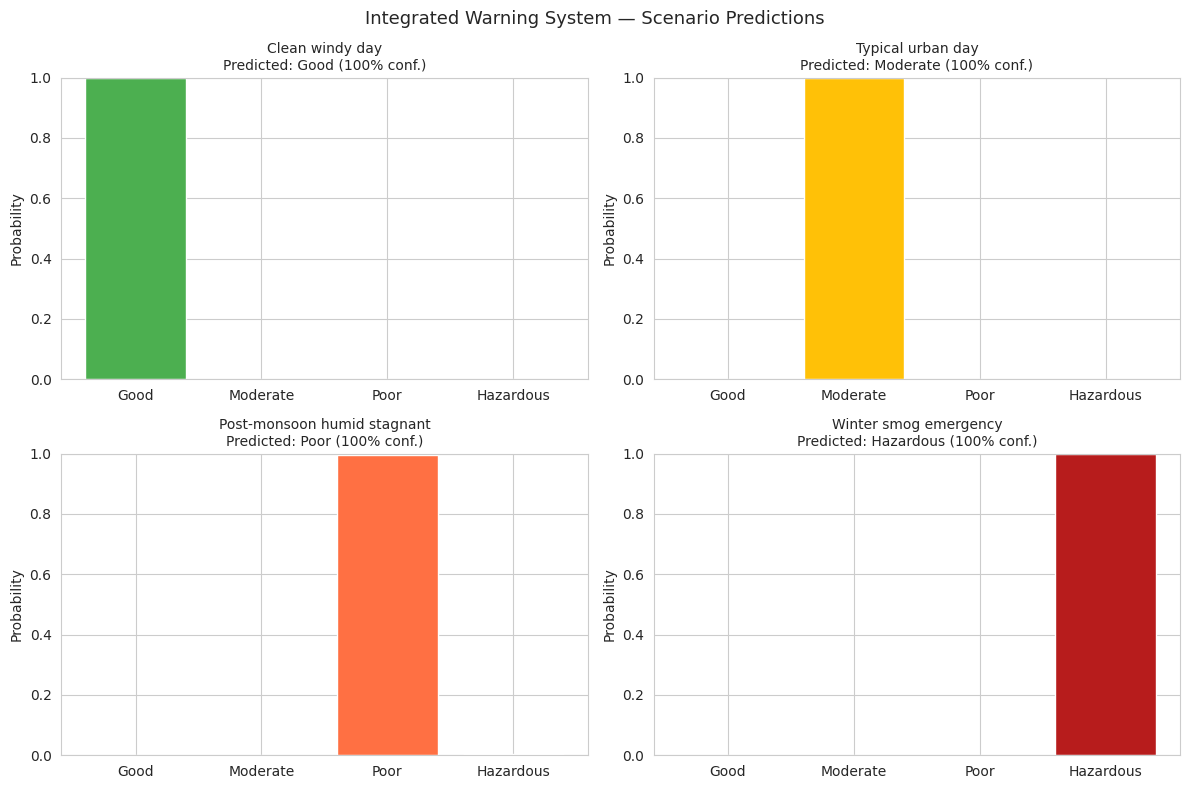

Saved dashboard visualization.


In [12]:
import numpy as np, pandas as pd, json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

df = pd.read_csv("data/air_quality_cleaned.csv")
features = ["PM2.5","PM10","NO2","SO2","CO","O3","Temperature","Humidity","WindSpeed","Pressure"]
X = df[features].values; y = df["AQI_Category"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler().fit(X_train)
best_model = MLPClassifier(hidden_layer_sizes=(16,), max_iter=2000, random_state=42)
best_model.fit(scaler.transform(X_train), y_train)

RECOMMENDATIONS = {
    "Good": "Air quality is satisfactory. Normal outdoor activities are safe for everyone.",
    "Moderate": "Acceptable air quality. Unusually sensitive individuals should consider reducing prolonged outdoor exertion.",
    "Poor": "Health effects possible for sensitive groups (children, elderly, respiratory/heart conditions). Limit prolonged outdoor exertion and consider masks (N95) outdoors.",
    "Hazardous": "Health warning of emergency conditions. Everyone should avoid outdoor physical activity, keep windows closed, use air purifiers, and follow local health advisories.",
}

def urban_air_quality_warning_system(sample: dict):
    """
    Integrated Urban Air-Quality Warning System.
    Input: dict of the 10 sensor readings.
    Output: predicted AQI category, confidence, and health recommendation.
    """
    x = np.array([[sample[f] for f in features]])
    x_s = scaler.transform(x)
    pred = best_model.predict(x_s)[0]
    proba = best_model.predict_proba(x_s)[0]
    confidence = float(np.max(proba))
    return {
        "predicted_category": pred,
        "confidence": round(confidence, 3),
        "recommendation": RECOMMENDATIONS[pred],
        "class_probabilities": {c: round(float(p),3) for c,p in zip(best_model.classes_, proba)}
    }

# Demonstrate the system on 4 representative scenarios
scenarios = {
    "Clean windy day": dict(zip(features, [45, 70, 25, 8, 0.5, 40, 28, 45, 6.5, 1015])),
    "Typical urban day": dict(zip(features, [105, 165, 48, 17, 1.2, 55, 27, 55, 2.5, 1012])),
    "Post-monsoon humid stagnant": dict(zip(features, [135, 210, 60, 22, 1.6, 35, 24, 78, 0.8, 1009])),
    "Winter smog emergency": dict(zip(features, [180, 260, 75, 28, 2.4, 30, 15, 65, 0.5, 1006])),
}

print("=== Integrated Urban Air-Quality Warning System: Demo ===\n")
results = {}
for name, s in scenarios.items():
    out = urban_air_quality_warning_system(s)
    results[name] = out
    print(f"Scenario: {name}")
    print(f"  Inputs: {s}")
    print(f"  --> Predicted category : {out['predicted_category']}  (confidence={out['confidence']})")
    print(f"  --> Recommendation     : {out['recommendation']}")
    print()

with open("data/q10_demo_results.json","w") as f:
    json.dump(results, f, indent=2)

# Visualization: dashboard-style summary of the 4 scenarios
fig, axes = plt.subplots(2,2, figsize=(12,8))
order = ["Good","Moderate","Poor","Hazardous"]
colors = {"Good":"#4CAF50","Moderate":"#FFC107","Poor":"#FF7043","Hazardous":"#B71C1C"}
for ax, (name, out) in zip(axes.flat, results.items()):
    probs = [out["class_probabilities"].get(c,0) for c in order]
    bars = ax.bar(order, probs, color=[colors[c] for c in order])
    ax.set_ylim(0,1)
    ax.set_title(f"{name}\nPredicted: {out['predicted_category']} ({out['confidence']*100:.0f}% conf.)", fontsize=10)
    ax.set_ylabel("Probability")
plt.suptitle("Integrated Warning System — Scenario Predictions", fontsize=13)
plt.tight_layout()
plt.savefig("figs/23_integrated_system_dashboard.png", dpi=140)
plt.show()
print("Saved dashboard visualization.")

---
# Appendix — System Workflow Diagram

Generates the end-to-end pipeline diagram used in the report (Question 1 deliverable).

saved workflow diagram


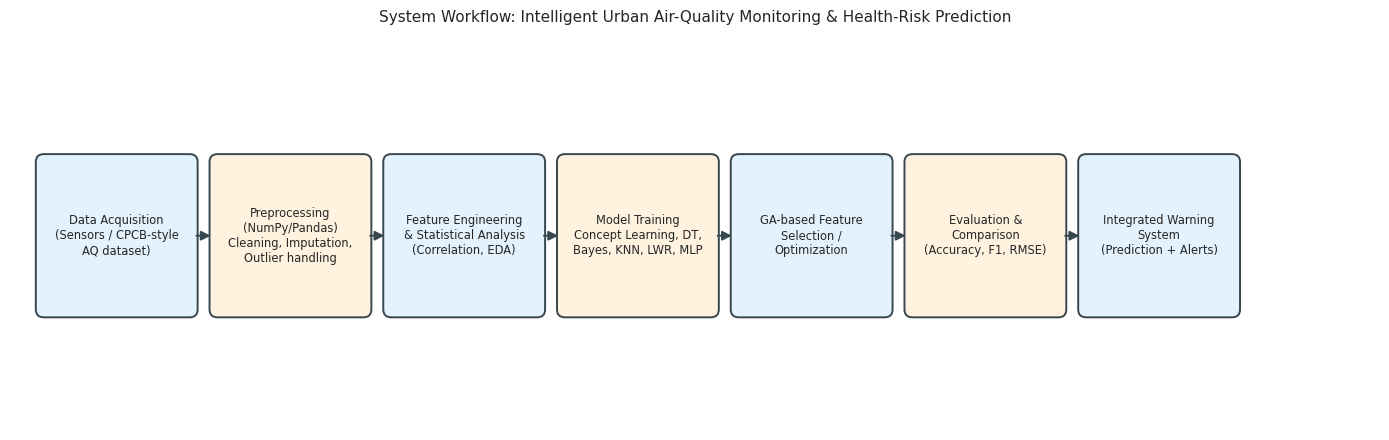

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14,4.5))
ax.set_xlim(0,13.8); ax.set_ylim(0,4); ax.axis("off")

stages = [
    "Data Acquisition\n(Sensors / CPCB-style\nAQ dataset)",
    "Preprocessing\n(NumPy/Pandas)\nCleaning, Imputation,\nOutlier handling",
    "Feature Engineering\n& Statistical Analysis\n(Correlation, EDA)",
    "Model Training\nConcept Learning, DT,\nBayes, KNN, LWR, MLP",
    "GA-based Feature\nSelection /\nOptimization",
    "Evaluation &\nComparison\n(Accuracy, F1, RMSE)",
    "Integrated Warning\nSystem\n(Prediction + Alerts)",
]
n = len(stages)
box_w, box_h = 1.55, 1.6
xs = [0.3 + i*1.75 for i in range(n)]
y = 1.2

for i, (x, text) in enumerate(zip(xs, stages)):
    color = "#E3F2FD" if i % 2 == 0 else "#FFF3E0"
    box = FancyBboxPatch((x, y), box_w, box_h, boxstyle="round,pad=0.04,rounding_size=0.08",
                          linewidth=1.4, edgecolor="#37474F", facecolor=color)
    ax.add_patch(box)
    ax.text(x+box_w/2, y+box_h/2, text, ha="center", va="center", fontsize=8.3, wrap=True)
    if i < n-1:
        arrow = FancyArrowPatch((x+box_w, y+box_h/2), (xs[i+1], y+box_h/2),
                                 arrowstyle='-|>', mutation_scale=14, color="#37474F", linewidth=1.4)
        ax.add_patch(arrow)

plt.title("System Workflow: Intelligent Urban Air-Quality Monitoring & Health-Risk Prediction", fontsize=11, pad=14)
plt.tight_layout()
plt.savefig("figs/00_system_workflow.png", dpi=150, bbox_inches="tight")
print("saved workflow diagram")

---
## Summary of Results

| Model | Test Accuracy |
|---|---|
| Decision Tree (entropy) | 0.753 |
| Naive Bayes | 0.880 |
| KNN (K=15, from scratch) | 0.887 |
| MLP (16 hidden, from scratch) | 0.970 |

The Genetic Algorithm converged on a 5-feature subset (PM2.5, PM10, NO2, SO2, CO) that
slightly **outperforms** the full 10-feature Decision Tree baseline (0.823 vs 0.813)
while using half the sensors — useful for cheaper real-world deployments.

All figures used in the assignment report were generated by the cells above and saved
to the `figs/` folder (also viewable inline above). Download the `data/` and `figs/`
folders from the Colab file browser if you need the raw outputs.
